Cell 1 — Run training

In [ ]:
import sys
from pathlib import Path

sys.path.append(str(Path("../src/training").resolve()))
sys.path.append(str(Path("../src/models").resolve()))
sys.path.append(str(Path("../src/data").resolve()))

from train import train

model, history = train(
    dataset_path = "../data/heat_dataset.npz",
    save_dir     = "../results",
    n_filters    = 32,
    batch_size   = 32,
    n_epochs     = 100,
    lr           = 1e-3,
    seed         = 42,
    patience     = 15,
)

Cell 2 — Inspect the model

In [ ]:
from cnn import HeatSurrogateCNN
import torch

model = HeatSurrogateCNN(n_filters=32)
print(f"Total parameters: {model.count_parameters():,}")

# trace tensor shapes through the network manually
# this is a good debugging habit
x = torch.zeros(1, 1, 64, 64)   # batch=1, channels=1, H=64, W=64
print(f"\nInput shape:  {x.shape}")

with torch.no_grad():
    out = model(x)
print(f"Output shape: {out.shape}")   # should be (1, 1, 64, 64)

Cell 3 — Load best model and do a quick visual check

In [4]:
import sys
from pathlib import Path
sys.path.append(str(Path("../src/training").resolve()))
sys.path.append(str(Path("../src/models").resolve()))
sys.path.append(str(Path("../src/data").resolve()))


Loaded best model from epoch 19
Best val loss: 0.000007
Dataset loaded successfully.
  Train : 8000 samples
  Val   : 1000 samples
  Test  : 1000 samples
  Input shape per sample : torch.Size([1, 64, 64])
  Metadata: {'n_samples': 10000, 'N': 64, 'L': 1.0, 'alpha': 0.01, 'dx': 0.015873015873015872, 'dt': 0.005668934240362811, 'r': 0.22499999999999998, 'stride': 10, 'seed': 42, 'max_blobs': 3, 'n_train': 8000, 'n_val': 1000, 'n_test': 1000, 'physical_dt_per_cnn_step': 0.05668934240362811}


C:\Users\adity\AppData\Local\Temp\ipykernel_59104\860208895.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


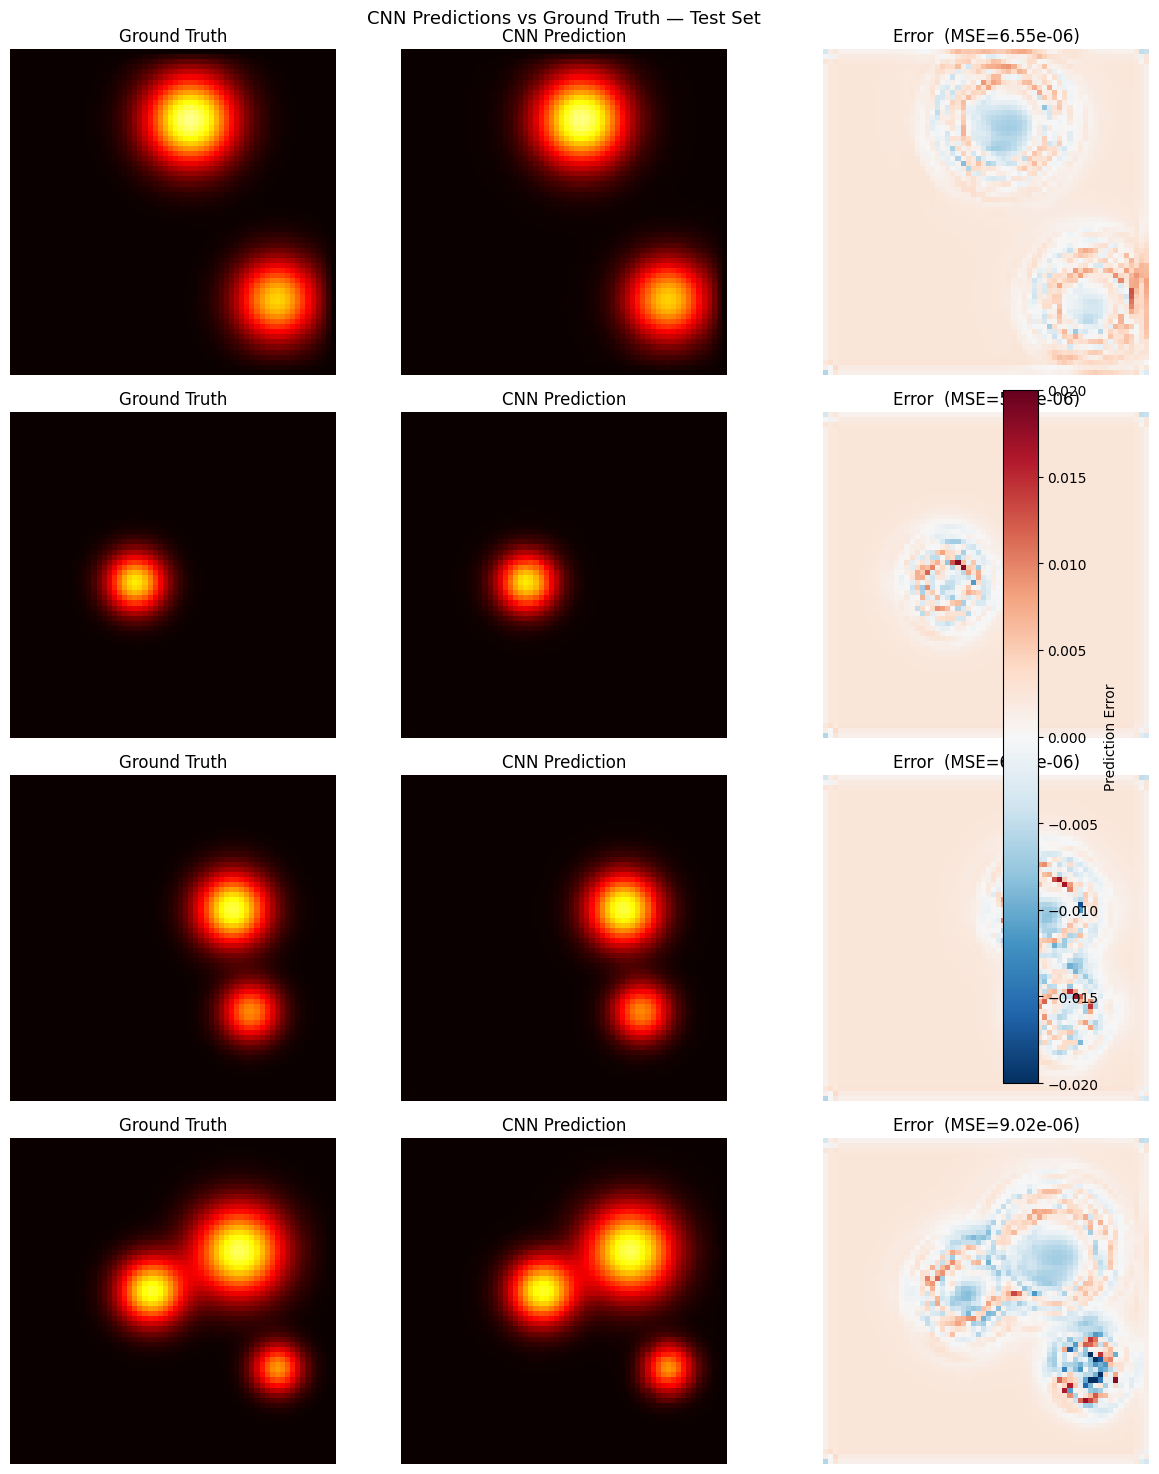

In [10]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import importlib.util

cnn_path = Path("../src/models/cnn.py").resolve()
spec = importlib.util.spec_from_file_location("cnn", cnn_path)
cnn = importlib.util.module_from_spec(spec)
spec.loader.exec_module(cnn)

HeatSurrogateCNN = cnn.HeatSurrogateCNN
from dataset import load_dataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# load best checkpoint
checkpoint = torch.load("../results/best_model.pt", map_location=torch.device(device))
model = HeatSurrogateCNN(n_filters=32).to(device)
model.load_state_dict(checkpoint["model_state"])
model.eval()

print(f"Loaded best model from epoch {checkpoint['epoch']}")
print(f"Best val loss: {checkpoint['val_loss']:.6f}")

# load test set
_, _, test_ds, _ = load_dataset("../data/heat_dataset.npz")

# predict on a few test samples
fig, axes = plt.subplots(4, 3, figsize=(12, 15))

for row in range(4):
    inp_tensor, tgt_tensor = test_ds[row]

    with torch.no_grad():
        pred_tensor = model(inp_tensor.unsqueeze(0).to(device))

    inp  = inp_tensor.squeeze().cpu().numpy()
    tgt  = tgt_tensor.squeeze().cpu().numpy()
    pred = pred_tensor.squeeze().cpu().numpy()
    err  = pred - tgt

    vmin, vmax = 0.0, max(inp.max(), tgt.max())

    axes[row, 0].imshow(tgt,  origin="lower", cmap="hot", vmin=vmin, vmax=vmax)
    axes[row, 0].set_title("Ground Truth")

    axes[row, 1].imshow(pred, origin="lower", cmap="hot", vmin=vmin, vmax=vmax)
    axes[row, 1].set_title("CNN Prediction")

    im = axes[row, 2].imshow(err, origin="lower", cmap="RdBu_r",
                              vmin=-0.02, vmax=0.02)
    axes[row, 2].set_title(f"Error  (MSE={np.mean(err**2):.2e})")

    for ax in axes[row]:
        ax.axis("off")

fig.colorbar(im, ax=axes[:, 2], shrink=0.6, label="Prediction Error")
plt.suptitle("CNN Predictions vs Ground Truth — Test Set", fontsize=13)
plt.tight_layout()
plt.savefig("../figures/milestone5_predictions.png", dpi=150)
plt.show()